# phy

In [1]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

import numpy as np

# For plotting
%matplotlib inline
# also try %matplotlib widget

import matplotlib.pyplot as plt

# for performance measurements
import time

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
batch_size = 1000 # Number of symbols we want to generate
num_bits_per_symbol = 6 # 64-QAM has four bits per symbol
binary_source = sionna.phy.mapping.BinarySource()
b = binary_source([batch_size, num_bits_per_symbol])
b

<tf.Tensor: shape=(1000, 6), dtype=float32, numpy=
array([[0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 1.],
       [0., 0., 0., 1., 0., 0.],
       ...,
       [1., 0., 0., 1., 0., 0.],
       [1., 1., 0., 0., 1., 0.],
       [1., 1., 0., 0., 0., 0.]], dtype=float32)>

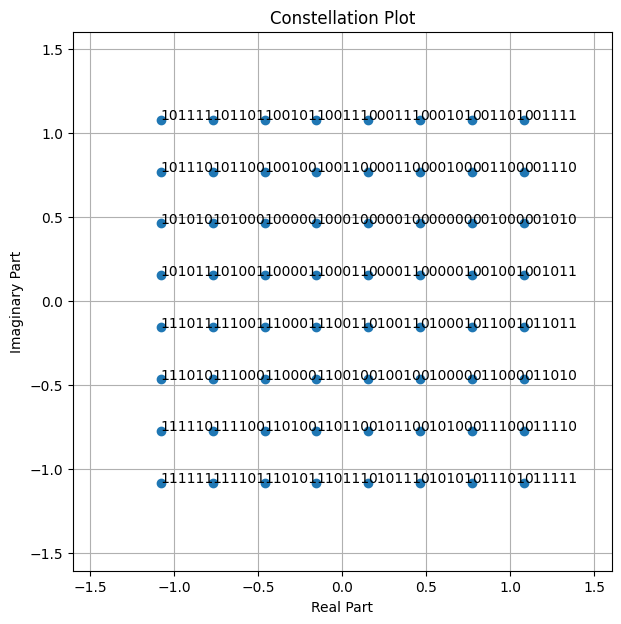

In [4]:
constellation = sionna.phy.mapping.Constellation("qam", num_bits_per_symbol)
constellation.show();

In [5]:
mapper = sionna.phy.mapping.Mapper(constellation=constellation)
x = mapper(b)
x[:10]

<tf.Tensor: shape=(10, 1), dtype=complex64, numpy=
array([[ 0.46291006+0.15430336j],
       [ 0.7715168 +0.15430336j],
       [ 0.46291006+0.7715168j ],
       [ 1.0801235 +0.46291006j],
       [ 1.0801235 -0.7715168j ],
       [ 0.46291006-0.7715168j ],
       [-0.15430336+0.15430336j],
       [-0.15430336+0.7715168j ],
       [-0.15430336-0.7715168j ],
       [ 0.15430336-1.0801235j ]], dtype=complex64)>

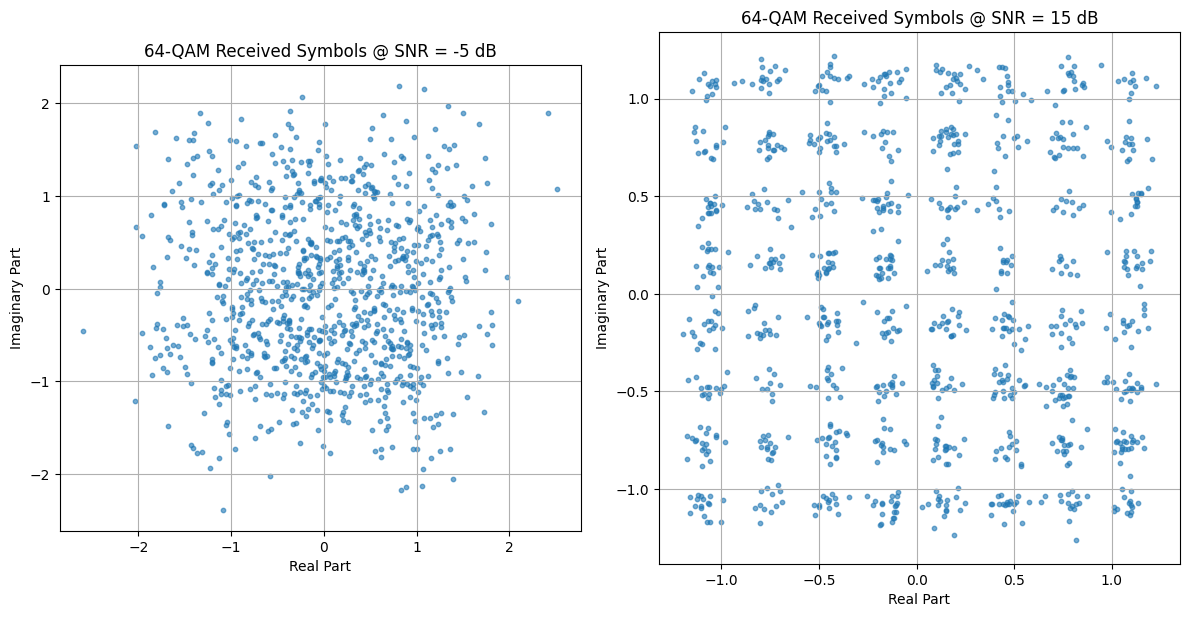

In [6]:
awgn = sionna.phy.channel.AWGN()
snr_list = [-5, 15]
fig, axs = plt.subplots(1, 2, figsize=(12,6))

for i, snr_db in enumerate(snr_list):
    no = sionna.phy.utils.ebnodb2no(snr_db,
                        num_bits_per_symbol=num_bits_per_symbol,
                        coderate=1.0) # Coderate set to 1 as we do uncoded transmission here
    y = awgn(x, no)
    axs[i].scatter(np.real(y), np.imag(y), s=10, alpha=0.6)
    axs[i].set_aspect("equal", adjustable="box")
    axs[i].set_xlabel("Real Part")
    axs[i].set_ylabel("Imaginary Part")
    axs[i].grid(True, which="both", axis="both")
    axs[i].set_title(f"64-QAM Received Symbols @ SNR = {snr_db} dB")

plt.tight_layout()
plt.show()


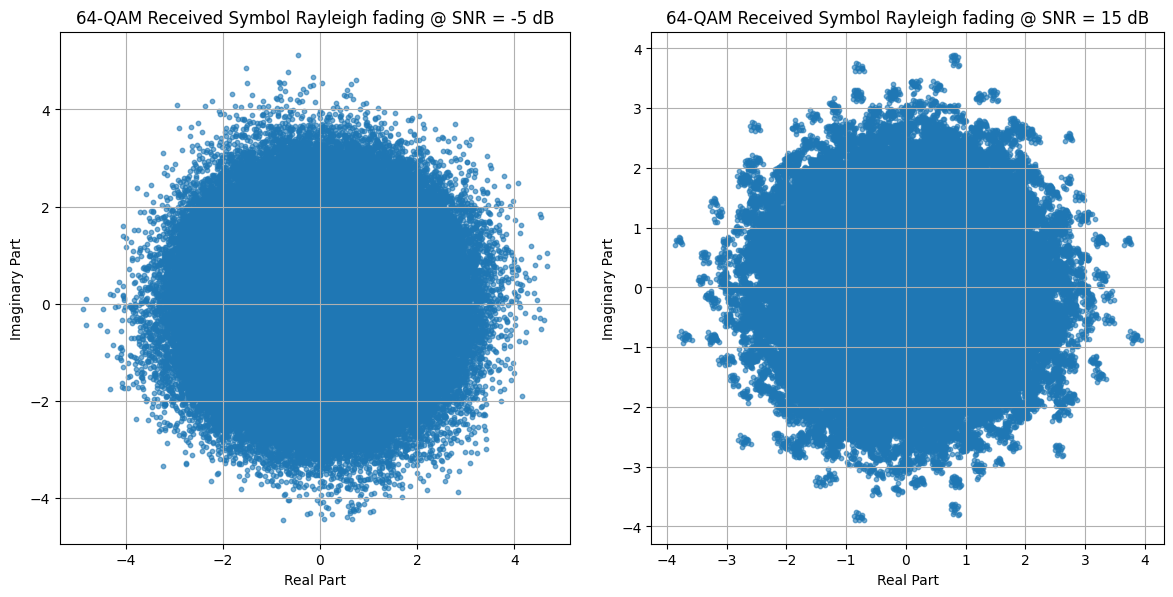

In [7]:
from sionna.phy.channel import FlatFadingChannel
flat_fading = sionna.phy.channel.RayleighBlockFading(
    num_rx=1, num_rx_ant=1, num_tx=1, num_tx_ant=1
)

snr_list = [-5, 15]
fig, axs = plt.subplots(1, 2, figsize=(12,6))

for i, snr_db in enumerate(snr_list):
    no = sionna.phy.utils.ebnodb2no(
        snr_db,
        num_bits_per_symbol=6,
        coderate=1.0
    )
    h, tau = flat_fading(batch_size=x.shape[0], num_time_steps=1)

    noise = tf.complex(
    tf.sqrt(no/2) * tf.random.normal(x.shape, dtype=tf.float32),
    tf.sqrt(no/2) * tf.random.normal(x.shape, dtype=tf.float32)
)

    y = tf.squeeze(h) * x + noise
    axs[i].scatter(np.real(y), np.imag(y), s=10, alpha=0.6)
    axs[i].set_aspect("equal", adjustable="box")
    axs[i].set_xlabel("Real Part")
    axs[i].set_ylabel("Imaginary Part")
    axs[i].grid(True, which="both", axis="both")
    axs[i].set_title(f"64-QAM Received Symbol Rayleigh fading @ SNR = {snr_db} dB")

    plt.tight_layout()
plt.show()


(100, 2)
(100, 2)
(100, 2)
(100, 2)
(100, 2)
(100, 2)
(100, 2)
(100, 2)
(100, 2)
(100, 2)
(100, 2)
(100, 2)
(100, 2)
(100, 2)
(100, 2)
(100, 2)
(100, 2)
(100, 2)


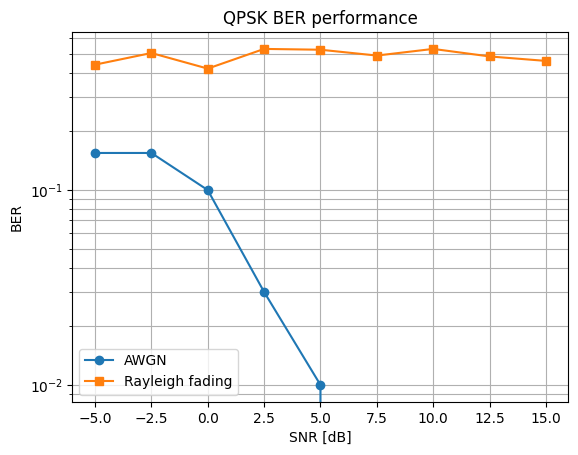

In [9]:

batch_size = 100
num_bits_per_symbol = 2         # QPSK
binary_source = sionna.phy.mapping.BinarySource()

constellation = sionna.phy.mapping.Constellation("qam", num_bits_per_symbol)
mapper = sionna.phy.mapping.Mapper(constellation=constellation)
demapper = sionna.phy.mapping.Demapper("maxlog", constellation=constellation, hard_out=True)

awgn = sionna.phy.channel.AWGN()
rayleigh = sionna.phy.channel.RayleighBlockFading(num_rx=1, num_rx_ant=1, num_tx=1, num_tx_ant=1)

def compute_ber(channel, snr_db):

    b = binary_source([batch_size, num_bits_per_symbol])
    x = mapper(b)

    no = sionna.phy.utils.ebnodb2no(snr_db, num_bits_per_symbol=num_bits_per_symbol, coderate=1.0)

    if isinstance(channel, sionna.phy.channel.AWGN):
        y = channel(x, no)   #
    else:
        # Rayleigh fading: h*x + n
        h, tau = channel(batch_size=batch_size, num_time_steps=1)
        h = tf.squeeze(h)  # (batch_size,)
        x = tf.reshape(x, [batch_size])

        noise = tf.complex(
    tf.sqrt(no/2) * tf.random.normal(x.shape, dtype=tf.float32),
    tf.sqrt(no/2) * tf.random.normal(x.shape, dtype=tf.float32)
)

        y = h * x + noise
        y = tf.reshape(y, [batch_size])


    b_hat = demapper(y, no)
    b_hat = tf.reshape(b_hat, [batch_size, num_bits_per_symbol])

    print(b_hat.shape)

    errors = tf.reduce_sum(tf.cast(tf.not_equal(b, b_hat), tf.float32))
    ber = errors / (batch_size * num_bits_per_symbol)
    return ber.numpy()

snr_list = np.linspace(-5, 15, 9)
ber_awgn = []
ber_rayleigh = []

for snr in snr_list:
    ber_awgn.append(compute_ber(awgn, snr))
    ber_rayleigh.append(compute_ber(rayleigh, snr))


plt.semilogy(snr_list, ber_awgn, "o-", label="AWGN")
plt.semilogy(snr_list, ber_rayleigh, "s-", label="Rayleigh fading")
plt.xlabel("SNR [dB]")
plt.ylabel("BER")
plt.title("QPSK BER performance")
plt.grid(True, which="both")
plt.legend()
plt.show()


In [10]:
print(len(snr_list), len(ber_awgn), len(ber_rayleigh))


9 9 9
